In [139]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r'Diwali_Sales_Data.csv', encoding='unicode_escape')     # encoding - for avoiding errors
df.head()    # show top 5 rows

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [8]:
df.shape      # rows, columns

(11251, 15)

In [9]:
df.info()      # show full information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [10]:
# drope unrelated / blank / empty columns
# axis = 1 -> target column
# inplace = True -> allow changes into dataframe / save changes

df.drop(['Status','unnamed1'], axis=1, inplace=True)

In [14]:
## check null values in dataframe
df.isnull().sum()      # count null values

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [18]:
## remove/drop null values rows from df
df.dropna(inplace=True)

In [24]:
# Change data type
# Amount  = float64 ---> int

df['Amount'] = df['Amount'].astype('int')

df['Amount'].dtypes

dtype('int64')

In [29]:
# view all columns

# m-1
# df.columns

# m-2
for i in df.columns:
    print(i)

User_ID
Cust_name
Product_ID
Gender
Age Group
Age
Marital_Status
State
Zone
Occupation
Product_Category
Orders
Amount


In [32]:
# Rename column name
df.rename(columns={'Marital_Status':'Shaddi'}).head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Shaddi,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877


In [33]:
# describe return statistic calculation on numeric data
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [42]:
# apply describe perticular columns

df[['Age', 'Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# Exploratory Data Analysis - EDA

## Gender

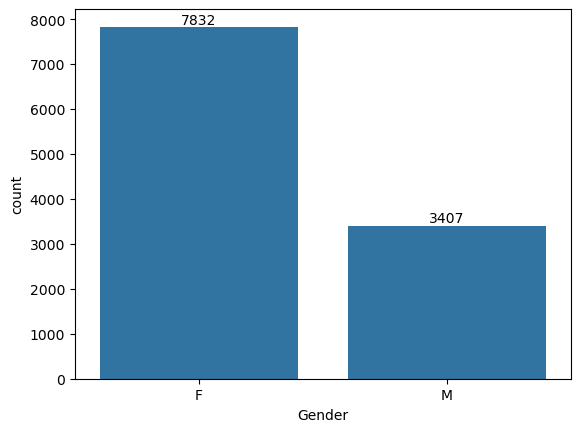

In [63]:
chrt = sns.countplot(x='Gender', data=df)

# show excect values to chart
for bar in chrt.containers:  
    chrt.bar_label(bar)

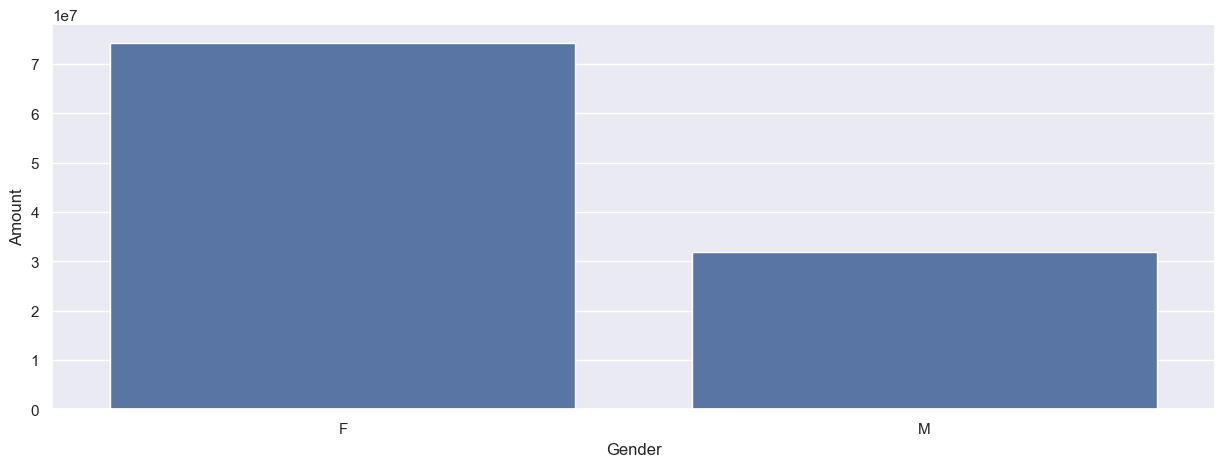

In [249]:
# gender wise - shoping Amount
s = df.groupby('Gender', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

chrt = sns.barplot(x='Gender', y='Amount', data = s)


From the above graph we can see that most of the buyers are Female and even purchashing power of the female are greater than man

## Age

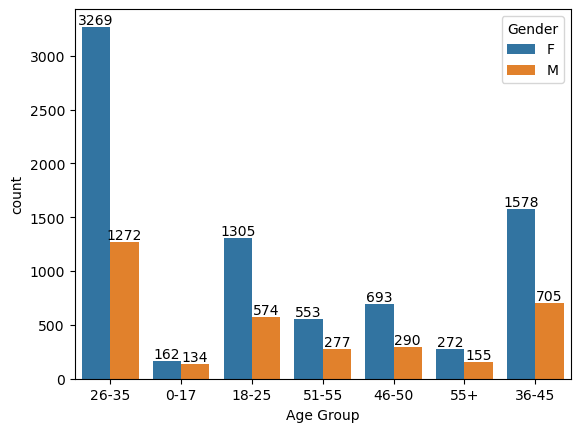

In [92]:
chrt = sns.countplot(data=df, x='Age Group', hue='Gender')
chrt

for bar in chrt.containers:
    chrt.bar_label(bar)

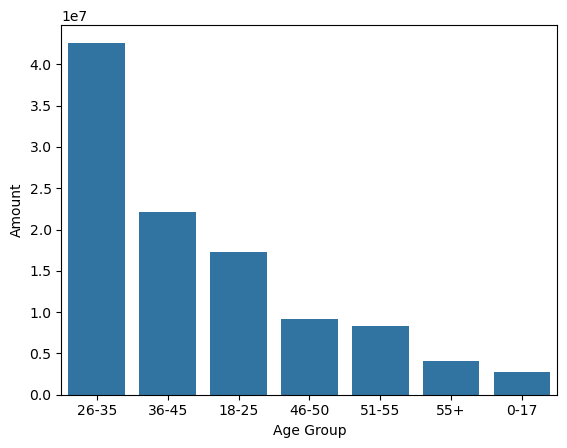

In [112]:
# Age wise spending Amount
d = df.groupby('Age Group',as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

ch = sns.barplot(data=d, x='Age Group', y='Amount' )

# for i in ch.containers:
#     ch.bar_label(i)

from above the graph we can see most spending buyers are age between 26-35 yrs females

## State

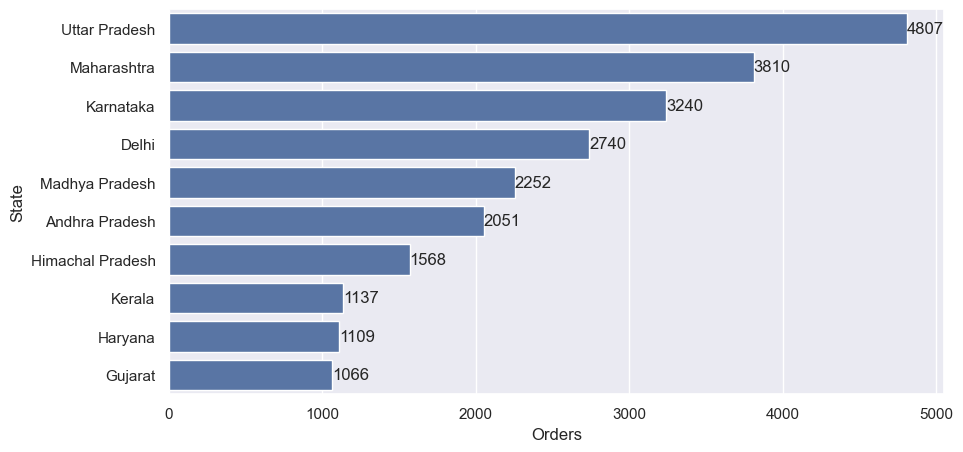

In [158]:
# total numbers of orders from top 10 staes

s_o = df.groupby('State')['Orders'].sum().sort_values(ascending=False).reset_index().head(10)
s_o

# sns.barplot(data=s_o, x='State', y='Orders')

# set figure size
sns.set(rc={'figure.figsize':(10,5)})
chrt = sns.barplot(data=s_o, x='Orders', y='State')
# add excect order values to states
for i in chrt.containers:
    chrt.bar_label(i)

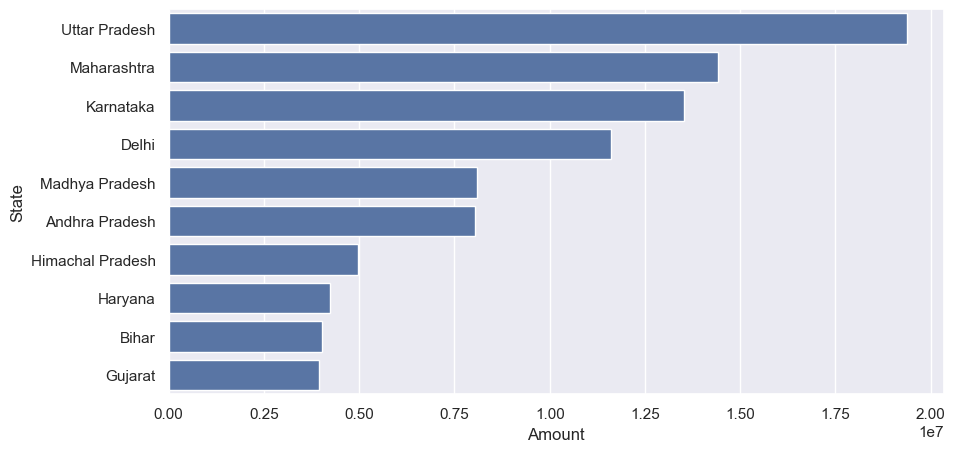

In [157]:
# total amount/sales form top 10 sates

s_o = df.groupby('State')['Amount'].sum().sort_values(ascending=False).reset_index().head(10)
s_o

# set figure size
sns.set(rc={'figure.figsize':(10,5)})
chrt = sns.barplot(data=s_o, x='Amount', y='State')
## add excect order values to states
# for i in chrt.containers:
#     chrt.bar_label(i)

## Marital Status

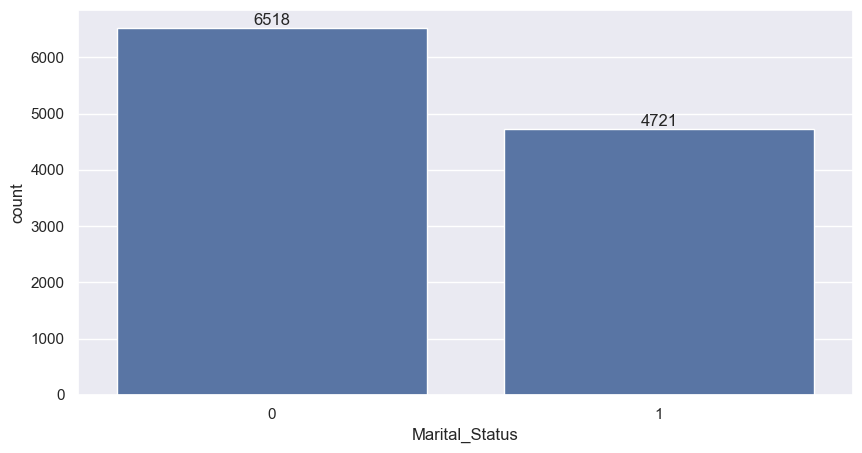

In [164]:
chrt = sns.countplot(data=df, x='Marital_Status')

# set figure size
sns.set(rc={'figure.figsize':(10,7)})
for i in chrt.containers:
    chrt.bar_label(i)

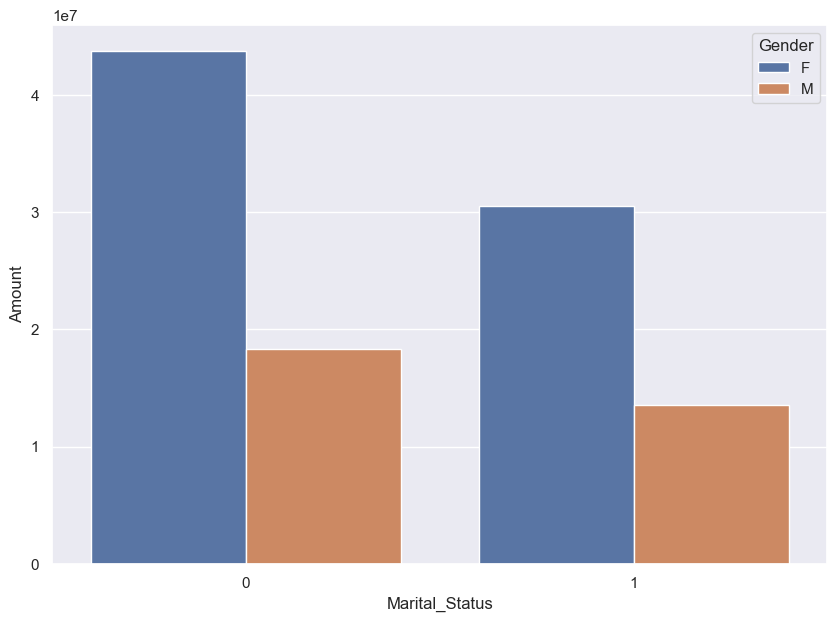

In [208]:
## marital status on amount based
# df1 = df['Marital_Status'].replace({0:'Unmarried', 1:'Married'})


m_s = df.groupby(['Marital_Status','Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

chrt = sns.barplot(data=m_s, x='Marital_Status', y='Amount', hue='Gender')

# for i in chrt.containers:
#     chrt.bar_label(i)

## Occupation

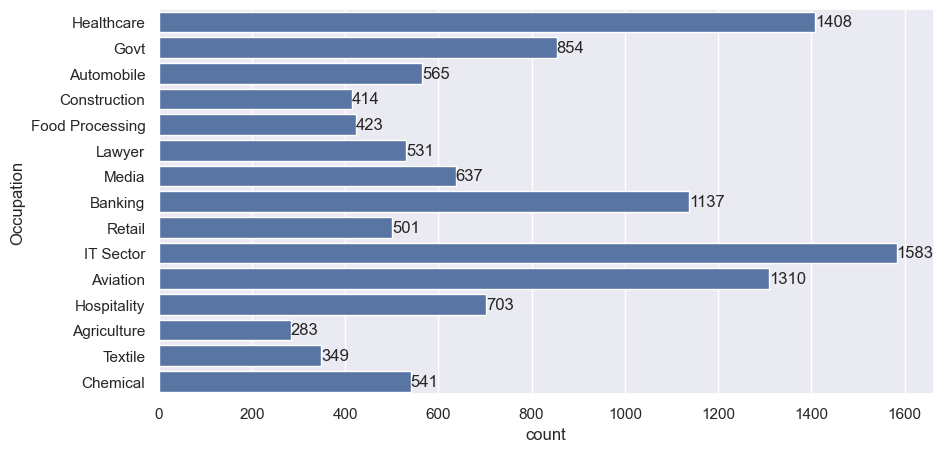

In [218]:
# set figure size

sns.set(rc={'figure.figsize':(10,5)})

chrt = sns.countplot(data=df, y='Occupation')

for i in chrt.containers:
    chrt.bar_label(i)

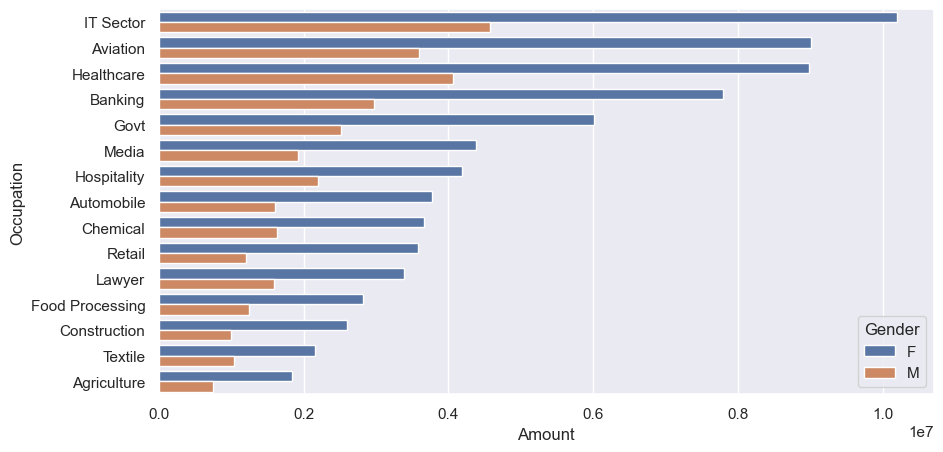

In [223]:
# occupation by amount

m_s = df.groupby(['Occupation','Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

chrt = sns.barplot(data=m_s, x='Amount', y='Occupation', hue='Gender')


from above chart we can see that most of the buyers are working in IT, Aviation and healthcare sectore 

In [224]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

<Axes: xlabel='count', ylabel='Product_Category'>

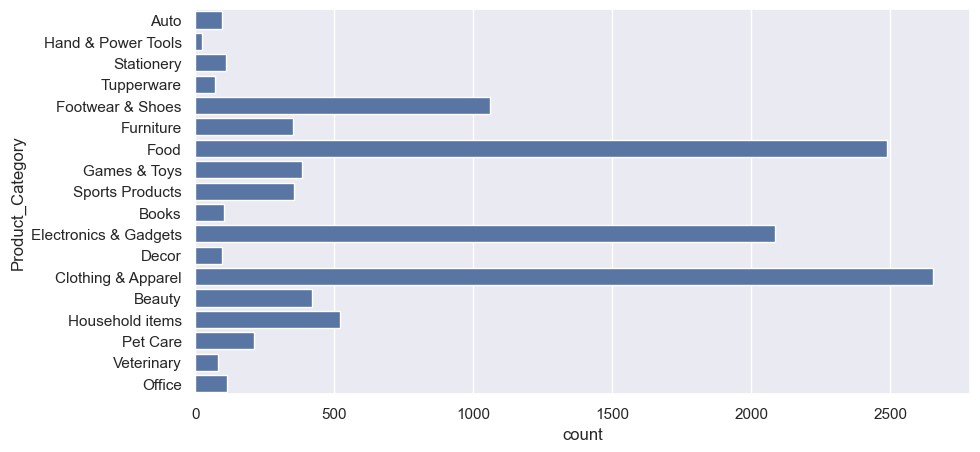

In [227]:
sns.set(rc={'figure.figsize':(10,5)})

sns.countplot(data=df, y='Product_Category')

<Axes: xlabel='Amount', ylabel='Product_Category'>

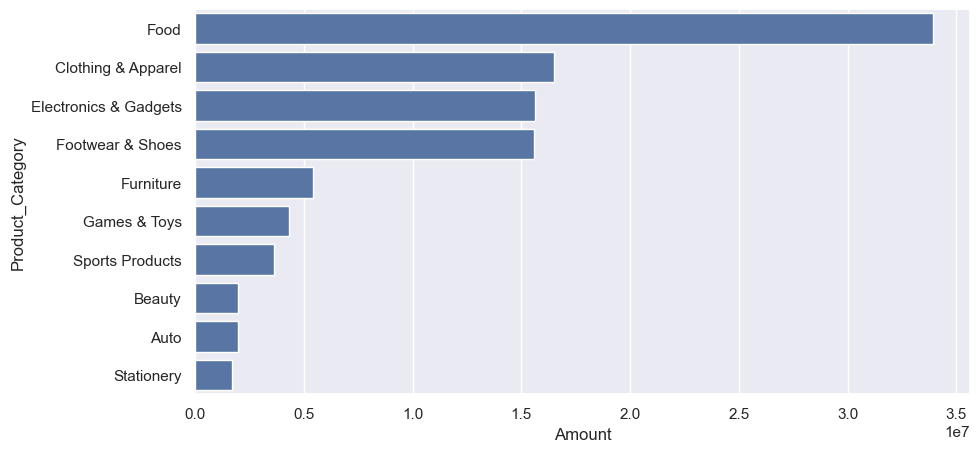

In [234]:
p_c = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
p_c

sns.barplot(data=p_c, y='Product_Category', x='Amount')

From above graph see we can that most of the product sold are Food, Clothing and Electronics catogories

<Axes: xlabel='Product_ID', ylabel='Amount'>

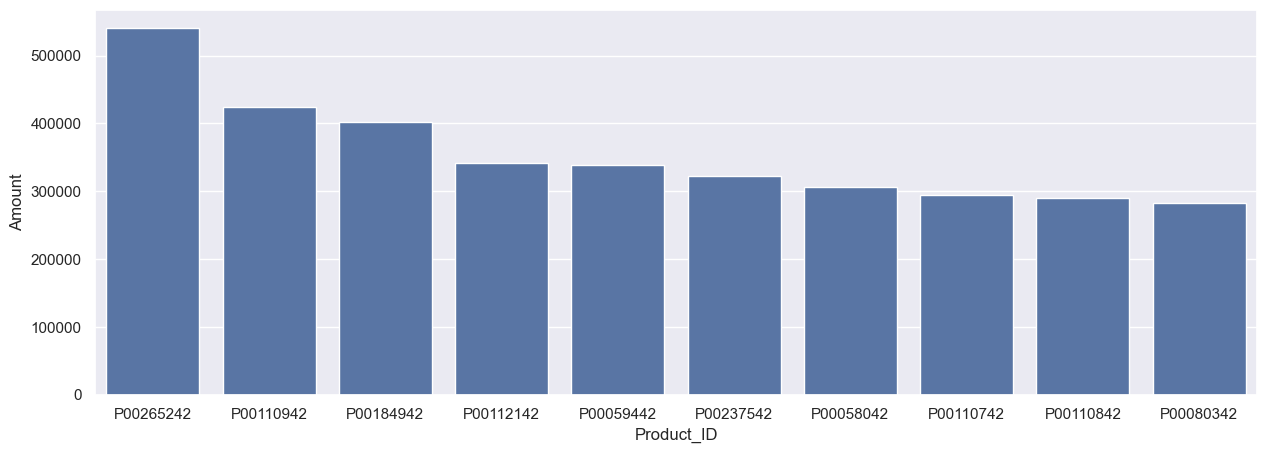

In [242]:
p_i = df.groupby(['Product_ID'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
p_i

sns.set(rc={'figure.figsize':(15,5)})

sns.barplot(data=p_i, x='Product_ID', y='Amount')

<Axes: xlabel='Product_ID'>

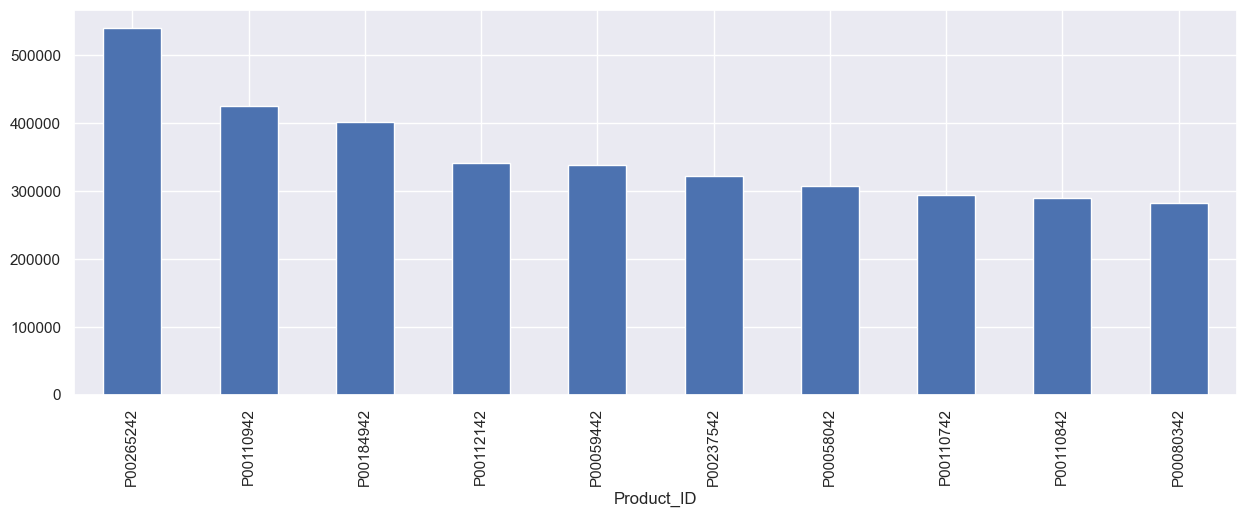

In [247]:
# Method 2
df.groupby('Product_ID')['Amount'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')


## Useful Insights ▽

### ⇨ Target Audience
<p>The primary buyers are married women aged 26-35 years.</p>

### ⇨ Top States
<p>Most of the sales volume comes from Uttar Pradesh (UP), Maharashtra, and Karnataka.</p>

### ⇨ Buyer Profession
<p>These women are predominantly working in the IT, Aviation, and Healthcare sectors</p>

### ⇨ Product Preferences
<p>The most popular product categories are Food, Clothing, and Electronics.</p>

## Business Suggestions ▽

### ⇨ Targeted Marketing
<p>Run social media ad campaigns (Instagram, Facebook) specifically targeting married women aged 26-35 living in UP, Maharashtra, and Karnataka. Showcase working-women-centric themes since a big chunk works in IT/Healthcare.</p>

### ⇨ Corporate Tie-ups
<p>Partner with major IT parks, hospitals, and aviation companies in Bangalore, Mumbai, and Noida to offer special Diwali corporate discounts or pop-up stalls.</p>

### ⇨ Product Bundling & Combos
<p>Create special Diwali combo offers that mix Food, Clothing, and Electronics (e.g., "Festive Outfit + Box of Premium Sweets" or "Kitchen Appliance + Grocery Hamper").</p>

### ⇨ Timing Optimization
<p>Since the target demographic consists of working professionals, launch your biggest sales, flash discounts, or email newsletters during weekends or late evenings when they are free to shop.</p>

## Conclusion

### ⇨ Married women age group 26-35 year from up, maharastra and karnataka working in IT, Aviation and Healthcare sector they are most liked product from food, cloting and electronic categories